# Análise Exploratória — Telco Customer Churn

Objetivo: entender a estrutura, qualidade e distribuições do dataset antes de construir o pipeline de pré-processamento.

**Seções**
1. Carregamento e visão geral
2. Qualidade dos dados
3. Variável target (Churn)
4. Features numéricas
5. Features categóricas
6. Correlações
7. Conclusões e prontidão dos dados

In [1]:
import sys
sys.path.insert(0, "..")

import logging
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.data.loader import load_raw
from src.config import TARGET_COLUMN, NUMERIC_COLS, CATEGORICAL_COLS

logging.basicConfig(level=logging.WARNING)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

## 1. Carregamento e Visão Geral

In [2]:
df = load_raw()
print(f"Dimensões: {df.shape[0]:,} registros × {df.shape[1]} colunas")
display(df.head())

Dimensões: 7,043 registros × 20 colunas


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Tipos de dados:")
print(df.dtypes.to_string())

Tipos de dados:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object


## 2. Qualidade dos Dados

In [3]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("Nenhum valor ausente após carregamento.")
else:
    print("Colunas com valores ausentes:")
    display(missing.to_frame("ausentes").assign(pct=lambda x: (x["ausentes"] / len(df) * 100).round(2)))

Nenhum valor ausente após carregamento.


In [5]:
# Duplicatas
n_dup = df.duplicated().sum()
print(f"Linhas duplicadas: {n_dup}")

Linhas duplicadas: 22


In [6]:
# Estatísticas descritivas — numéricas
display(df[NUMERIC_COLS].describe().round(2))

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2281.92
std,24.56,30.09,2265.27
min,0.00,18.25,18.80
25%,9.00,35.50,402.22
50%,29.00,70.35,1397.48
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


**Observação sobre `TotalCharges`**: no CSV original a coluna é do tipo string e contém 11 registros com valor em branco (clientes com `tenure = 0`). O `loader.py` converte para float e preenche os ausentes com a mediana.

## 3. Variável Target — Churn

,count,pct
Churn,,
No,5174,73.5
Yes,1869,26.5


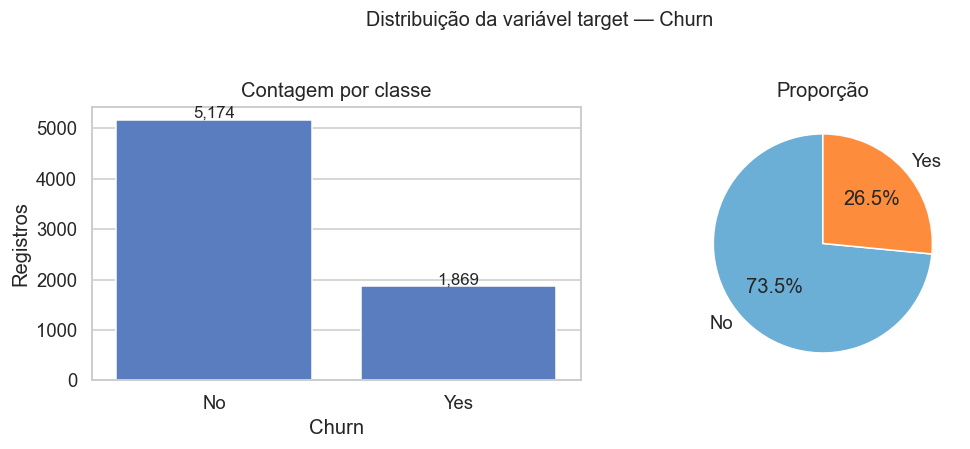


Razão de desbalanceamento (No:Yes): 2.8:1
→ Estratégia necessária: pos_weight no BCELoss ou class_weight='balanced' nas baselines.


In [7]:
churn_counts = df[TARGET_COLUMN].value_counts()
churn_pct = df[TARGET_COLUMN].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": churn_counts, "pct": churn_pct.round(1)})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x=TARGET_COLUMN, data=df, order=["No", "Yes"], ax=axes[0])
axes[0].set_title("Contagem por classe")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Registros")
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=11
    )

axes[1].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#6baed6", "#fd8d3c"]
)
axes[1].set_title("Proporção")

plt.suptitle("Distribuição da variável target — Churn", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

ratio = churn_counts["No"] / churn_counts["Yes"]
print(f"\nRazão de desbalanceamento (No:Yes): {ratio:.1f}:1")
print("→ Estratégia necessária: pos_weight no BCELoss ou class_weight='balanced' nas baselines.")

## 4. Features Numéricas

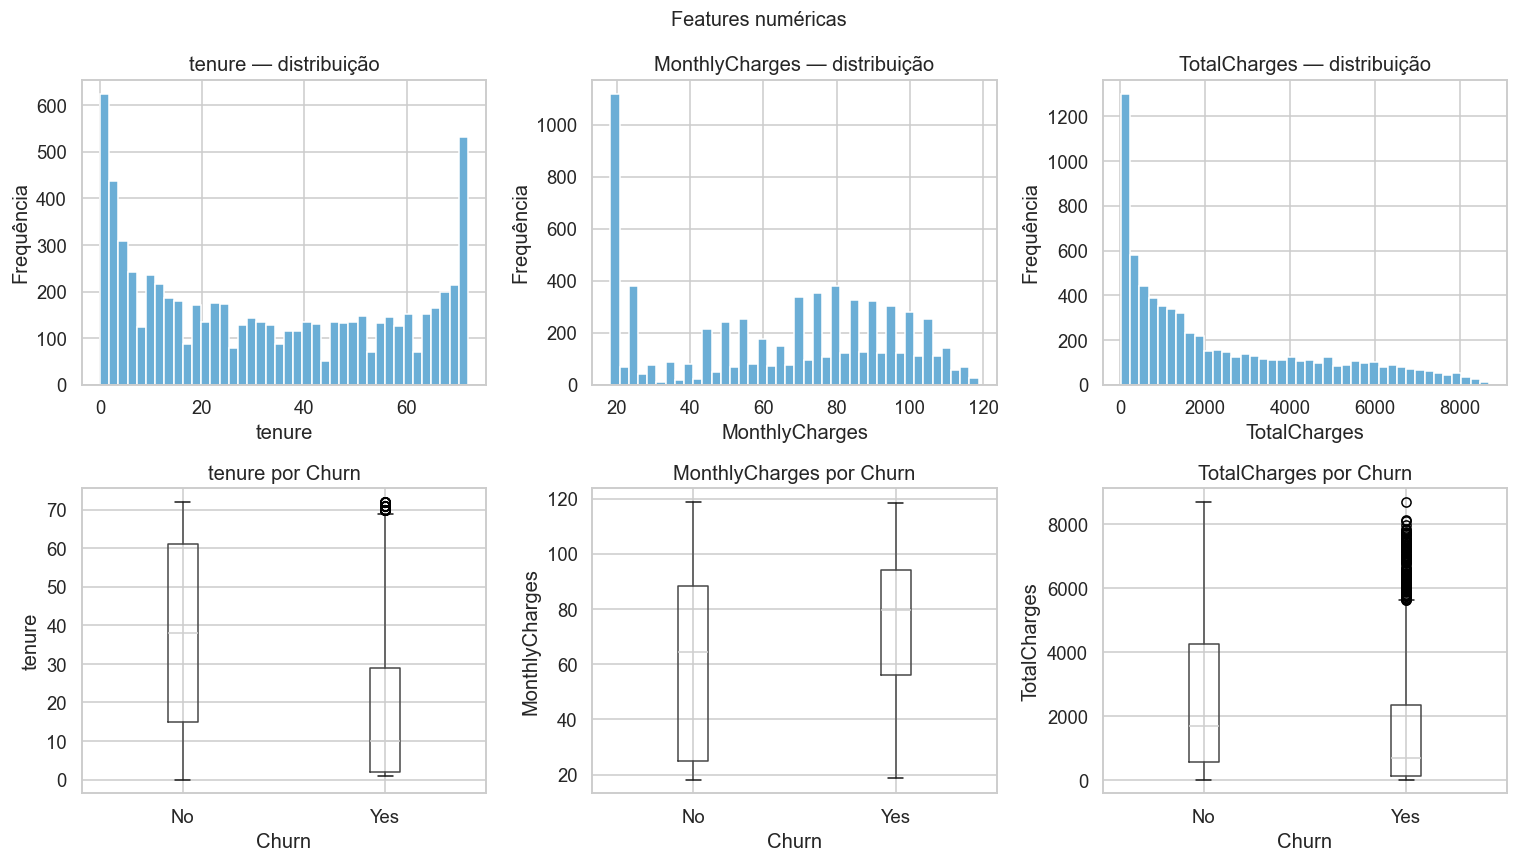

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(NUMERIC_COLS):
    # Histograma
    ax_hist = axes[0, i]
    df[col].hist(bins=40, ax=ax_hist, color="#6baed6", edgecolor="white")
    ax_hist.set_title(f"{col} — distribuição")
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel("Frequência")

    # Boxplot por target
    ax_box = axes[1, i]
    df.boxplot(column=col, by=TARGET_COLUMN, ax=ax_box)
    ax_box.set_title(f"{col} por Churn")
    ax_box.set_xlabel("Churn")
    ax_box.set_ylabel(col)

plt.suptitle("Features numéricas", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Outliers via IQR
print("Outliers por IQR (fora de Q1-1.5*IQR / Q3+1.5*IQR):")
for col in NUMERIC_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col}: {outliers} ({outliers/len(df)*100:.1f}%)")

Outliers por IQR (fora de Q1-1.5*IQR / Q3+1.5*IQR):
  tenure: 0 (0.0%)
  MonthlyCharges: 0 (0.0%)
  TotalCharges: 0 (0.0%)


## 5. Features Categóricas

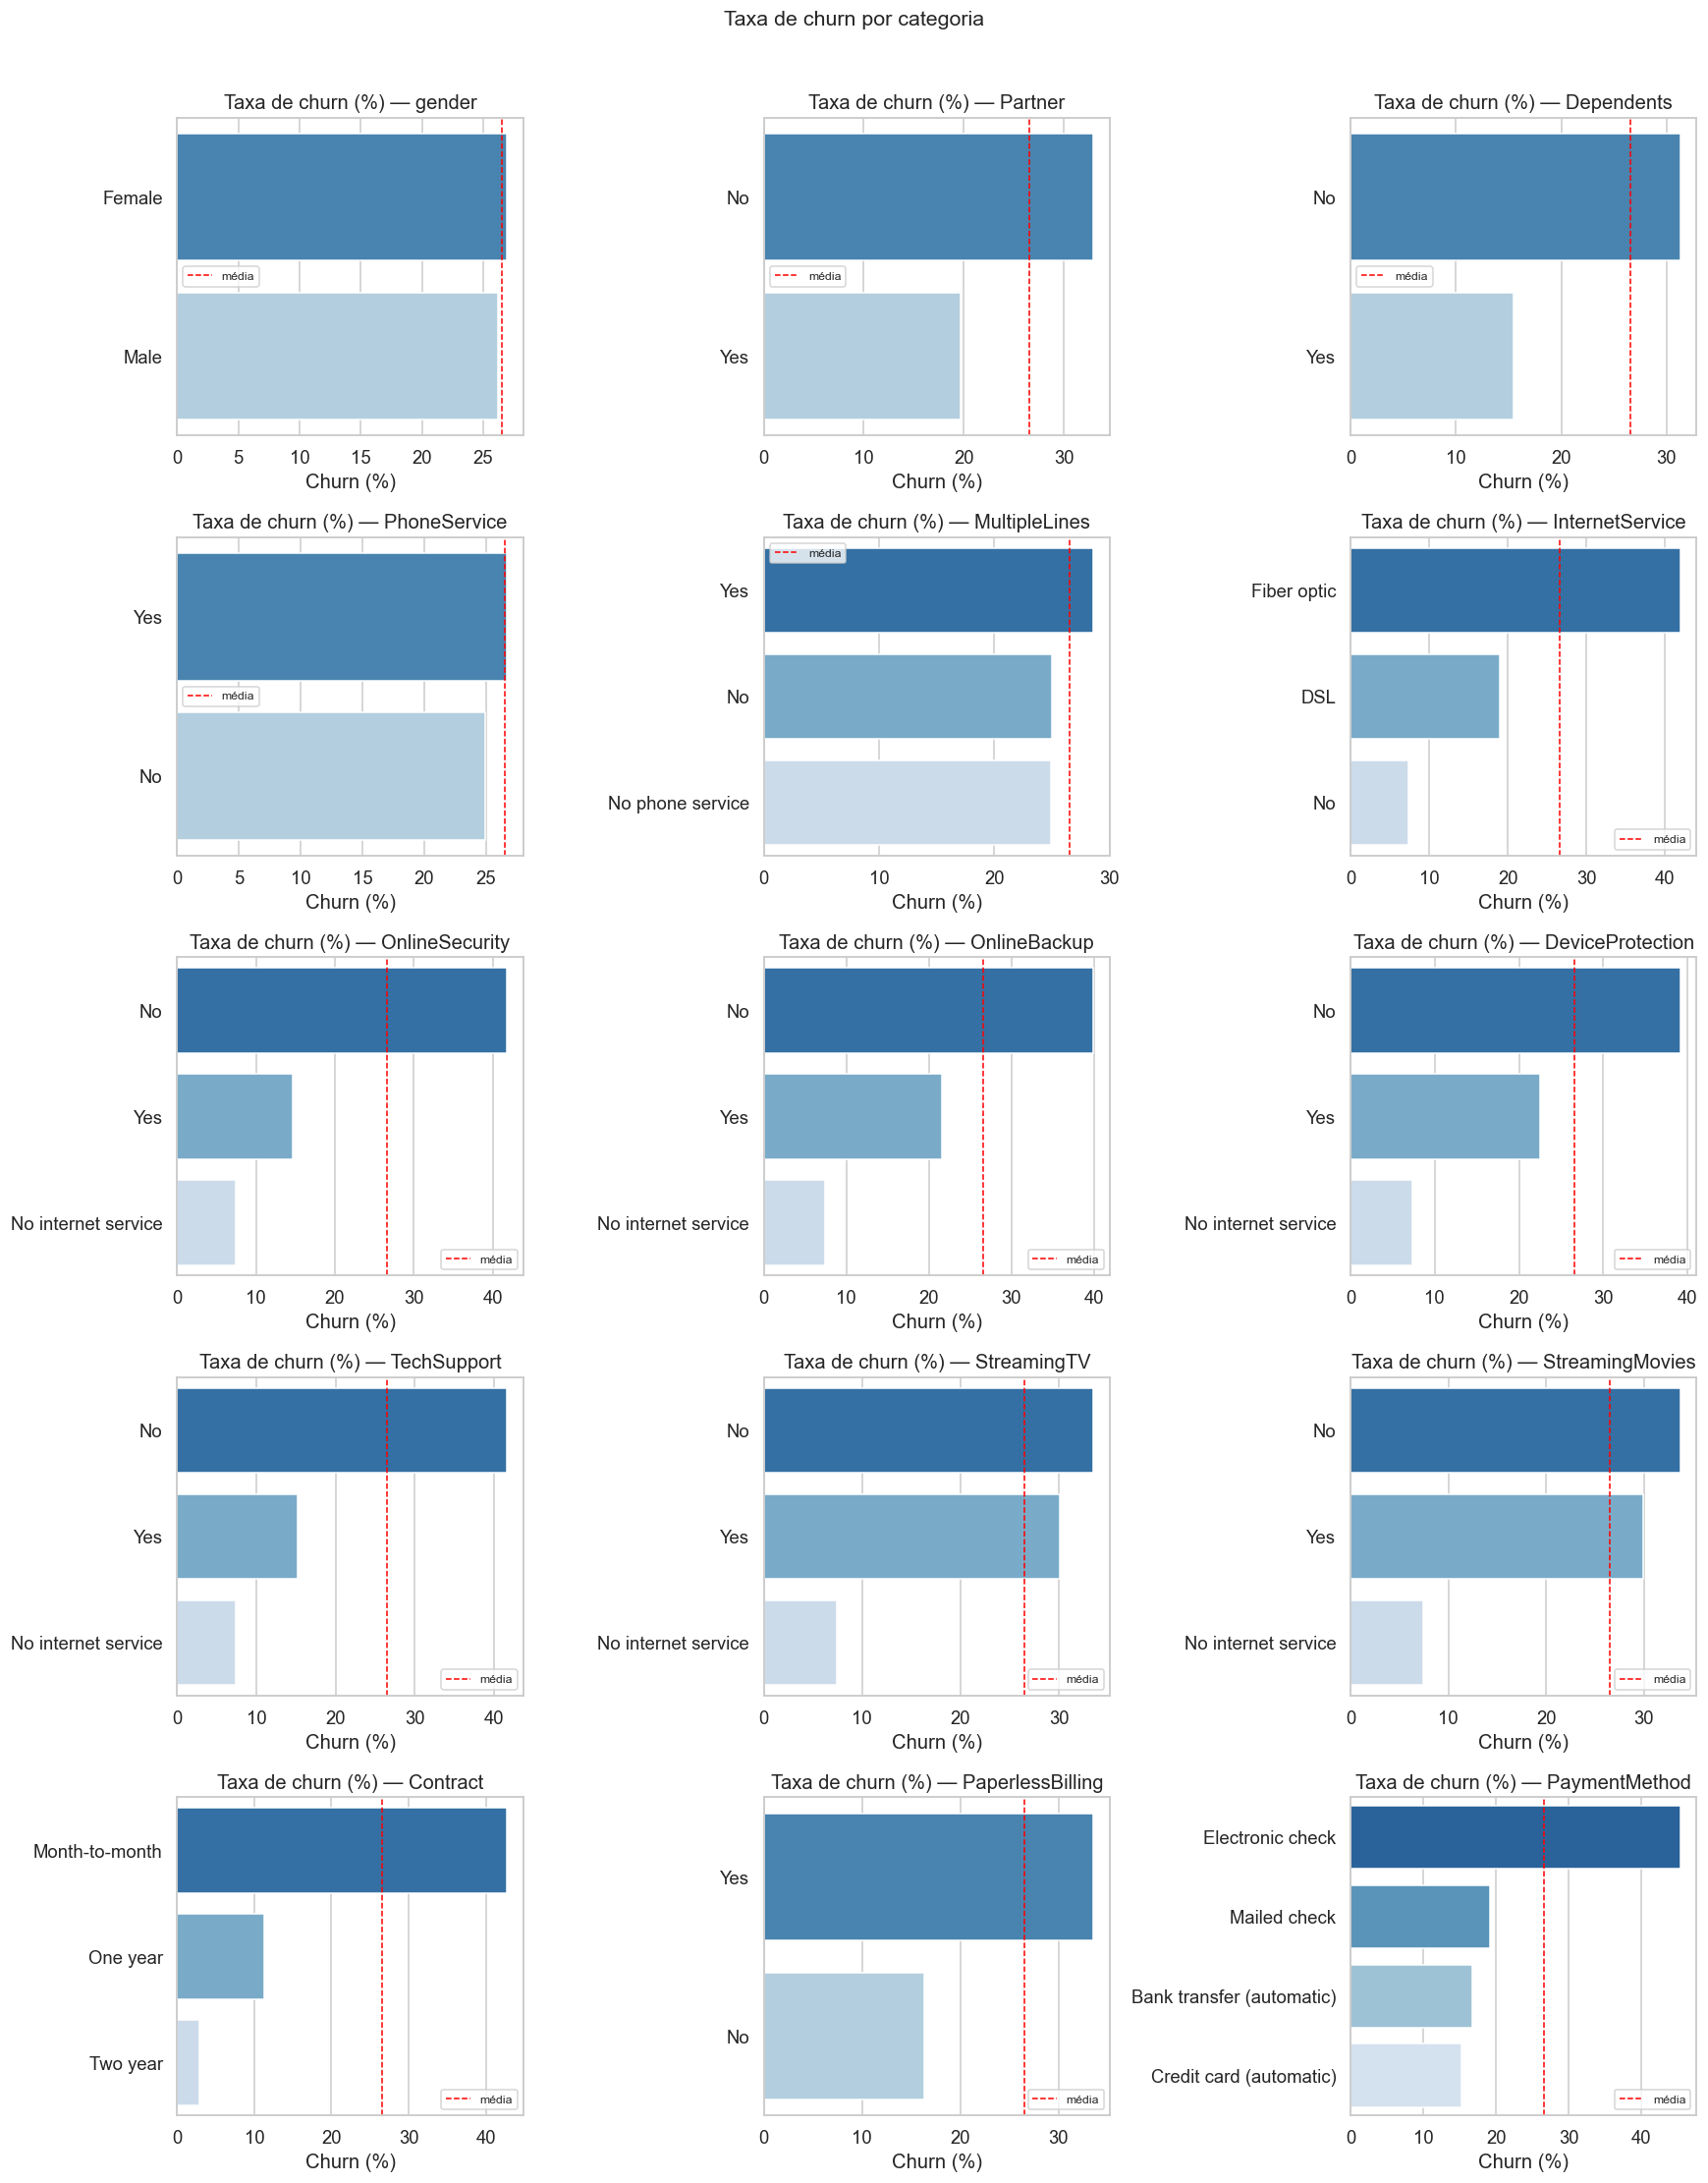

In [10]:
# Taxa de churn por categoria para cada feature
n_cols = 3
n_rows = -(-len(CATEGORICAL_COLS) // n_cols)  # teto

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    churn_rate = (
        df.groupby(col)[TARGET_COLUMN]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )
    sns.barplot(x=churn_rate.values, y=churn_rate.index, ax=axes[i], palette="Blues_r")
    axes[i].set_title(f"Taxa de churn (%) — {col}")
    axes[i].set_xlabel("Churn (%)")
    axes[i].set_ylabel("")
    axes[i].axvline(churn_pct["Yes"], color="red", linestyle="--", linewidth=1, label="média")
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Taxa de churn por categoria", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# SeniorCitizen — binária 0/1 (não está em CATEGORICAL_COLS)
senior_churn = df.groupby("SeniorCitizen")[TARGET_COLUMN].apply(lambda x: (x == "Yes").mean() * 100).round(1)
print("Taxa de churn por SeniorCitizen:")
print(senior_churn.rename({0: "Não idoso", 1: "Idoso"}))

Taxa de churn por SeniorCitizen:
SeniorCitizen
Não idoso    23.6
Idoso        41.7
Name: Churn, dtype: float64


## 6. Correlações

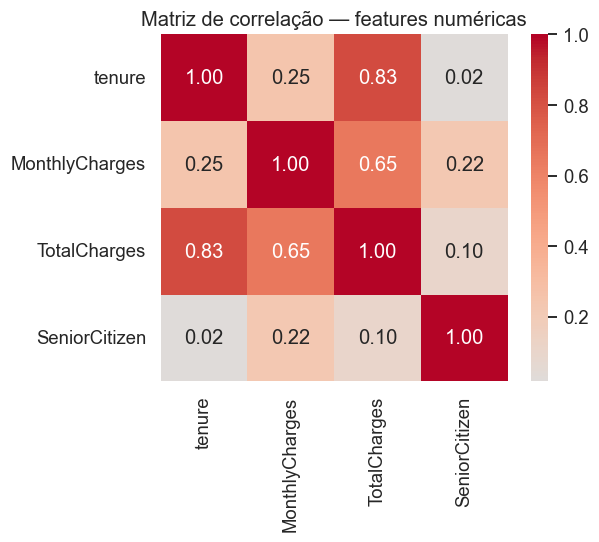

In [12]:
# Correlação entre features numéricas e SeniorCitizen
num_cols_ext = NUMERIC_COLS + ["SeniorCitizen"]
corr_matrix = df[num_cols_ext].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax
)
ax.set_title("Matriz de correlação — features numéricas")
plt.tight_layout()
plt.show()

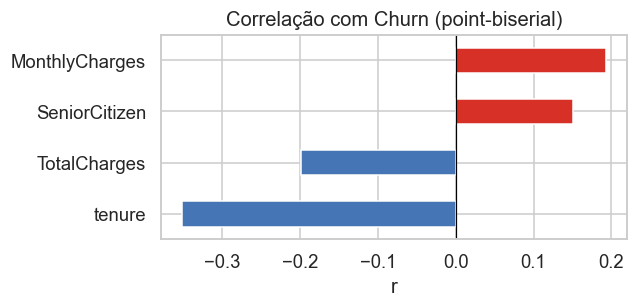

In [13]:
# Correlação point-biserial: numéricas vs Churn binário
df_corr = df.copy()
df_corr["churn_bin"] = (df_corr[TARGET_COLUMN] == "Yes").astype(int)

corr_with_target = df_corr[num_cols_ext + ["churn_bin"]].corr()["churn_bin"].drop("churn_bin").sort_values()

fig, ax = plt.subplots(figsize=(6, 3))
corr_with_target.plot(kind="barh", ax=ax, color=["#d73027" if v > 0 else "#4575b4" for v in corr_with_target])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação com Churn (point-biserial)")
ax.set_xlabel("r")
plt.tight_layout()
plt.show()

## 7. Conclusões e Prontidão dos Dados

In [14]:
print("=" * 60)
print("SUMÁRIO DA ANÁLISE EXPLORATÓRIA")
print("=" * 60)

print(f"\n• Volume: {len(df):,} registros, {df.shape[1]} colunas")
print(f"• Desbalanceamento: {churn_pct['Yes']:.1f}% churn — razão {ratio:.1f}:1")
print(f"• Valores ausentes após loader: {df.isnull().sum().sum()}")
print(f"• Duplicatas: {df.duplicated().sum()}")

print("\nProblemas tratados no loader:")
print("  - TotalCharges convertida de string para float (11 registros preenchidos com mediana)")
print("  - customerID removida (identificador sem valor preditivo)")

print("\nDecisões para o pipeline de pré-processamento:")
print("  - Numéricas (tenure, MonthlyCharges, TotalCharges): StandardScaler")
print("  - Categóricas: OneHotEncoder (drop='first' para evitar multicolinearidade)")
print("  - SeniorCitizen (0/1): manter como numérica ou tratar como binária")
print("  - Desbalanceamento: pos_weight no BCELoss + class_weight='balanced' nas baselines")

print("\nFeatures mais discriminativas (hipótese inicial):")
print("  - tenure: clientes novos têm churn muito mais alto")
print("  - Contract: Month-to-month apresenta taxa de churn elevada")
print("  - InternetService: Fiber optic com alta taxa de churn")
print("  - TechSupport / OnlineSecurity: ausência desses serviços aumenta churn")

SUMÁRIO DA ANÁLISE EXPLORATÓRIA

• Volume: 7,043 registros, 20 colunas
• Desbalanceamento: 26.5% churn — razão 2.8:1
• Valores ausentes após loader: 0
• Duplicatas: 22

Problemas tratados no loader:
  - TotalCharges convertida de string para float (11 registros preenchidos com mediana)
  - customerID removida (identificador sem valor preditivo)

Decisões para o pipeline de pré-processamento:
  - Numéricas (tenure, MonthlyCharges, TotalCharges): StandardScaler
  - Categóricas: OneHotEncoder (drop='first' para evitar multicolinearidade)
  - SeniorCitizen (0/1): manter como numérica ou tratar como binária
  - Desbalanceamento: pos_weight no BCELoss + class_weight='balanced' nas baselines

Features mais discriminativas (hipótese inicial):
  - tenure: clientes novos têm churn muito mais alto
  - Contract: Month-to-month apresenta taxa de churn elevada
  - InternetService: Fiber optic com alta taxa de churn
  - TechSupport / OnlineSecurity: ausência desses serviços aumenta churn
